# RTTOV概要
RTTOVモデルの重要な特徴は、以下２点 \
・順方向（直接）放射伝達計算が可能 \
・入力状態ベクトル値によって指定された状態空間内の位置における状態ベクトル変数に対する放射輝度の勾配の計算。（ヤコビアンの計算） \ 

以下、利用可能なものの例とユーザーガイドで対応するセクション \
紫外／可視／赤外(波長0.24～100 µm（波数100～42000 cm-1)): LBLRTM \
マイクロ波帯(1～800 GHz)：Liebe-89 MPM（Liebe, 1989）\
・晴天シミュレーション \
・太陽放射（セクション8.1） \
・単一の雲頂気圧と雲量に基づく単純なUV/可視/IR雲スキーム（セクション8.2） \
・水文降水粒子とエアロゾルの散乱処理（セクション8.4） \
・地表面放射率と反射率の処理（セクション8.3） \
・ハイパースペクトルIRサウンダーをシミュレートするための主成分ベースのモデル（セクション8.6）。 \
・非局所熱力学的平衡効果の補正（セクション8.5） \
・マイクロ波センサーチャネルにおけるゼーマン効果の処理（セクション8.7.1）。 \

# 使用方法



# 使い方
RTTOVをPythonから利用するには、rttov_wrapper_f2pyまたはpyrttovパッケージを使用する。
使用するセンサーに対応した係数ファイル（rtcoefファイル）を、NWP SAFのRTTOV係数ファイルダウンロードページから取得。
## RTCOEFについて
特定の衛星センサーに対応した放射伝達計算を行うための係数が含まれており、これらの係数は、RTTOVが大気プロファイルや表面特性を入力した時に、各センサーのチャンネルにおける放射輝度を迅速かつ正確に計算するために必要。
#### センサーおよびチャンネル情報
センサー名、プラットフォーム、チャンネル番号、中心波長や周波数など
#### 光学的厚さの予測係数
大気中の温度、湿度、気圧などのプロファイルから、各チャンネルの光学的厚さを予測するための係数
#### スペクトル応答関数（SRF）
各チャンネルのスペクトル応答関数が含まれており、これによりセンサーの実際の応答を模擬可能
#### バンド補正係数
広帯域チャンネルにおける放射輝度の計算精度を向上させるための補正係数が含まれています。
#### Planck加重情報
特定のチャンネルにおいて、Planck関数による加重が行われているかどうかの情報。
#### 予測子（Predictors）のバージョン
RTTOVでは、異なるバージョンの予測子（例：v7、v9、v13）が使用されており、それぞれのバージョンに対応した係数が含まれている。

### hydrotable（ハイドロテーブル）
目的: 水蒸気や雲粒子（雨、雪、霰、雲水、氷晶）などの水系粒子（hydrometeors）の光学特性を定義。 \
内容: 各水系粒子の散乱や吸収の特性を、粒子のサイズや形状に基づいて記述。これにより、雲や降水の影響を考慮した放射伝達計算が可能。 \
使用例: RTTOV-SCATTを用いたマイクロ波帯の散乱計算や、雲の影響を含むシミュレーションに使用。 \

### aertable（エアロゾルテーブル）
目的: エアロゾル粒子（黄砂、海塩、煙、都市汚染物質など）の光学特性を定義。 \
内容: 各エアロゾルタイプの散乱や吸収の特性を、粒子の種類やサイズ分布に基づいて記述。これにより、大気中のエアロゾルの影響を考慮した放射伝達計算が可能。 \
使用例: 可視・赤外帯域におけるエアロゾルの影響を含むシミュレーションや、エアロゾルの同化研究に使用。 \

### rttov v13 54L,101L
目的: RTTOV v13で使用される光学的厚さの予測子（predictors）を、各気圧レベルで定義した係数ファイル。 \
内容: 温度、水蒸気、オゾンなどの大気成分のプロファイルに基づいて、各センサーのチャンネルにおける光学的厚さを予測するための係数が含まれる。 \
使用例: RTTOV v13を使用した放射伝達シミュレーションに使用。 \

### 101Lと54Lの違い
101L: 101の圧力レベル、100の層 \
54L: 54の圧力レベル、53の層.  \
これらのレベルは、RTTOVが光学的厚さ（optical depth）を計算する際の基準となり。入力プロファイルがこれらのレベルと一致しない場合、RTTOVは内部で補間を行う。 
用途は以下の通り。 \
101L: 高分解能の赤外サウンダー（例：IASI、AIRS）向けに設計。これらのセンサーは、より詳細な大気情報を取得するため、細かいレベル分解能が必要。 \
54L: 主にマイクロ波センサーや中・低分解能の赤外センサー向けに使用。計算速度を重視する場合や、必要な精度が比較的低い場合に適する。 \
RTTOVのユーザーガイドでは、可能であれば101Lの係数ファイルを使用することが推奨。 \

### 変数について
rtcoef ファイルは、含まれる可変ガスの種類によって分類される。ファイル名やディレクトリ構造から、どのガスが可変として扱われているかを識別できる。 \
これらのファイルは、センサーごとで異なる。 \
rtcoef_o3.dat：オゾン（O₃）のみを可変ガスとして考慮。 \
rtcoef_o3co2.dat：オゾン（O₃）と二酸化炭素（CO₂）を可変ガスとして考慮。 \
rtcoef_7gas.dat：オゾン（O₃）、二酸化炭素（CO₂）、一酸化炭素（CO）、亜酸化窒素（N₂O）、メタン（CH₄）、二酸化硫黄（SO₂）など、複数の微量気体を可変ガスとして考慮。\

## pyrttovについて
・pyrttov パッケージには、Options、Profiles、ProfilesScatt、Rttov、RttovScatt、Atlas クラスが含まれる。これらのクラスは多くのチェック機構があり動作は遅いがC++安全なバージョンと同様に使われる。
### 使い方
・以下の手順で利用 \
• RTTOVオプションの設定 \
• 機器の読み込み \
• オプションで放射率アトラスまたはBRDFアトラスの初期化 \
• 表面の放射率と反射率の指定 \
• シミュレーションするプロファイルデータの指定 \
• RTTOVの呼び出し \
• シミュレーション出力へのアクセス \
• メモリの解放 \

### 主なオプション
ADKBT：輝度温度の感度（アドジョイント）計算を有効。 \
Aerosols：エアロゾルの影響を考慮した計算を有効。 \
ApplyRegLimits：回帰モデルの適用範囲を制限することで、異常な入力に対する計算の安定性を向上。 \
BtOvercastCalc：完全に曇った条件下での明度温度の計算を有効。 \
CH4Data, CO2Data, COData, N2OData, O3Data, SO2Data：各種微量気体（メタン、二酸化炭素、一酸化炭素、亜酸化窒素、オゾン、二酸化硫黄）のデータを使用するかどうかを設定 \
CLWData：雲の液体水（Cloud Liquid Water）のデータを使用するかどうか。 \
Hydrometeors：降水粒子（雨、雪、氷など）による散乱の影響を考慮した計算を有効。 \
MwSeaEmisModel：マイクロ波帯における海面放射率モデルのバージョンを指定(3はSURFEM-Ocean MW sea surface emissivity model)。 \
UseFoamFraction：海面の泡（フォーム）による放射率の変化を考慮するかどうか。 \
Nthreads：計算に使用するスレッド数を指定します。マルチスレッド処理を行うことで、計算速度の向上。 \
StoreRad, StoreTrans, StoreEmisRefl：計算結果として、放射輝度、透過率、放射率・反射率などの中間データを保存するかどうかを設定。 \
Verbose：計算中の詳細なログ出力を有効。 \


In [46]:
import os,sys
sys.path.append("/home/knakata/program/mycode/kn-general_analysis_tools")
from knool.satellite.rtm import rttov
import numpy as np
import matplotlib.pyplot as plt

{1: '/home/knakata/program/mycode/kn-general_analysis_tools/knool/satellite/rtm/conf/mw_seaice_clear.yaml', 2: '/home/knakata/program/mycode/kn-general_analysis_tools/knool/satellite/rtm/conf/mw_seaice_scatt.yaml'}
OK


Load successful >>>>> inst_id : 1, nchannels : 14.
 2025/05/19  18:11:25  Load coefficients:
 2025/05/19  18:11:25  /home/knakata/program/software/rttov140/rtcoef_rttov14/rttov13pred54L/rtcoef_gcom-w_1_amsr2_o3.dat
Deallocating this inst_id.
Atlas deallocated.
 2025/05/19  18:11:25  Dropping coefficients:


(2, 14)
vertical polarized TB for ocean


MW emissivity atlas loaded successfully
 2025/05/19  18:11:25  /home/knakata/program/software/rttov140/rtcoef_rttov14/rttov13pred54L/rtcoef_gcom-w_1_amsr2_o3.dat
 2025/05/19  18:11:26  Running RTTOV using nthreads =    1 and nprofs_per_call =        1


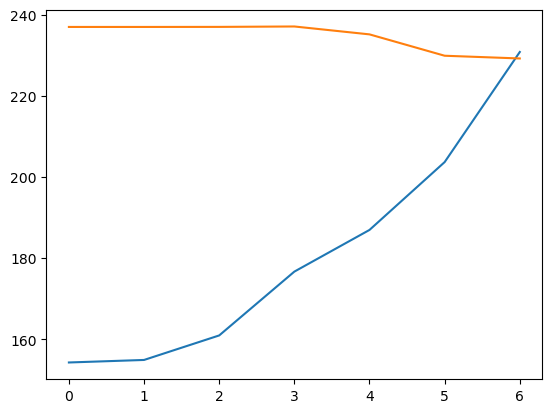

horizontal polarized TB for sea ice


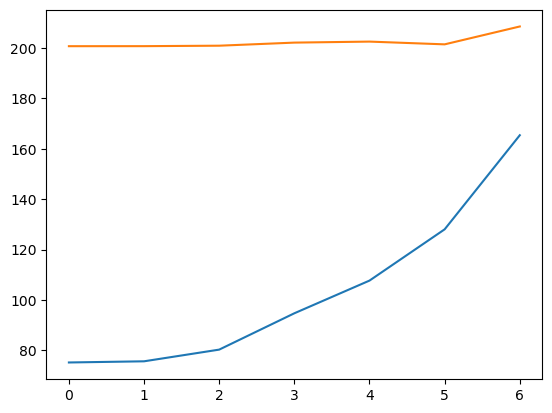

In [47]:
class _profiles_data():
    pass

profiles_data=_profiles_data()

nprofiles = 2
nlevels = 37
nlayers= nlevels-1
nsurfaces = 1
rttov.BaseConf.keys()
conf = rttov.BaseConf.read_conf(1) # 0 = open water, 1 = sea ice

T_surf_water = 268.0  # surface air temp for water profile (K)
T_surf_ice   = 255.0  # surface air temp for ice profile (K)
T_top   = 210.0       # temperature at top of atmosphere (K)
profiles_data.T = np.vstack([np.linspace(T_top, T_surf_water, nlayers), np.linspace(T_top, T_surf_ice, nlayers)])  # shape (2,37)

q_surf_water = 0.0032  # ~3.2 g/kg at surface
q_surf_ice   = 0.0008  # ~0.8 g/kg at surface (colder air holds less moisture)
q_top = 1.0E-9
profiles_data.Q =np.vstack([np.linspace(q_top, q_surf_water, nlayers),np.linspace(q_top, q_surf_water, nlayers)])


profiles_data.SurfType = np.array([[1, 0],    # Profile 0: surftype=1 (sea), watertype=0
                              [2, 0]]).reshape([2,1,2])   # Profile 1: surftype=2 (sea-ice), watertype=0

# Surface geometry: latitude, longitude, elevation for each profile
# [nprofiles,nsurfaces,9]: skin T, salinity, snow_frac, foam_frac, fastem_coefsx5
profiles_data.Skin = np.zeros([nprofiles, 9])
# Profile 0 (open water)
profiles_data.Skin[0,0] = 271.0   # skin temperature of water (K)
profiles_data.Skin[0,1] = 35.0    # sea water salinity (psu, typical ocean)
profiles_data.Skin[0,2] = 0.0     # snow fraction (not applicable to open water)
profiles_data.Skin[0,3] = 0.0     # foam fraction (let RTTOV/FASTEM compute based on wind)
# fastem_coefs[0..4] leave as 0 to use model's default behavior
# Profile 1 (sea-ice)
profiles_data.Skin[1,0] = 268.0   # skin temperature of sea-ice surface (K)
profiles_data.Skin[1,1] = 0.0     # salinity (not a water surface, but set 0)
profiles_data.Skin[1,2] = 0.0     # snow fraction on sea-ice (50% of surface covered by snow)
profiles_data.Skin[1,3] = 0.0     # foam fraction (no foam on ice)
# fastem_coefs for ice not used; leave as 0
# (The Skin array includes placeholders for FASTEM parameters; RTTOV uses these for ocean surface calc)
# near_surface[5][nsurfaces][nprofiles]: 2m t, 2m q, 10m wind u, v, wind fetch
# Profile 0 (open water) Profile 1 (sea-ice)
profiles_data.NearSurface = np.zeros([nprofiles, 5])
profiles_data.NearSurface[0,:] = np.array([268.0, 0.0032, 5.0, 0.0, 100000.])
profiles_data.NearSurface[1,:] = np.array([255.0, 0.0012, 5.0, 0.0, 100000.])

myprofile=rttov.Profiles_tool(nprofiles, nlevels, nsurfaces, conf, gas_units=1)
profiles_data.Skin=myprofile.expand_nsurfaces(profiles_data.Skin)
profiles_data.NearSurface=myprofile.expand_nsurfaces(profiles_data.NearSurface)
myprofile.set_PHalf_geomspace(p_surface=1013.0,p_top=0.1)
myprofile.set_general_profiles(date=[2015, 5, 1, 0, 0, 0], geom=[80.0,0.0,0.0])
myprofile.set_profiles_from_obj(profiles_data)
myprofile.confirm_profiles()


coefs={"FileCoef": r"/home/knakata/program/software/rttov140/rtcoef_rttov14/rttov13pred54L/rtcoef_gcom-w_1_amsr2_o3.dat"}
       # "FileHydrotable": r"/home/knakata/program/software/rttov140/rtcoef_rttov14/hydrotable_mw/rttov_hydrotable_gcom-w_amsr2.dat"}

myrttov = rttov.RTTOV_tools(nprofiles, nlevels, nsurfaces, conf, coefs)
myrttov.load_profiles(myprofile.profiles)
myrttov.load_emissivity_atlas()
myrttov.run(mode="forward")

bt=myrttov.get_clearSky_BT()
print(bt.shape)
print("vertical polarized TB for ocean")
plt.plot(bt.T[0::2])
plt.show()
print("horizontal polarized TB for sea ice")
plt.plot(bt.T[1::2])
plt.show()

{1: '/home/knakata/program/mycode/kn-general_analysis_tools/knool/satellite/rtm/conf/mw_seaice_clear.yaml', 2: '/home/knakata/program/mycode/kn-general_analysis_tools/knool/satellite/rtm/conf/mw_seaice_scatt.yaml'}
[[1 0]]
OK


 2025/05/19  18:11:29  Load coefficients:
Load successful >>>>> inst_id : 2, nchannels : 14.
 2025/05/19  18:11:29  /home/knakata/program/software/rttov140/rtcoef_rttov14/rttov13pred54L/rtcoef_gcom-w_1_amsr2_o3.dat
Deallocating this inst_id.
Atlas deallocated.
 2025/05/19  18:11:29  Dropping coefficients:
 2025/05/19  18:11:29  /home/knakata/program/software/rttov140/rtcoef_rttov14/rttov13pred54L/rtcoef_gcom-w_1_amsr2_o3.dat


(3, 14)
vertical polarized TB for Ts=271,281,291


MW emissivity atlas loaded successfully
 2025/05/19  18:11:30  Running RTTOV using nthreads =    1 and nprofs_per_call =        1


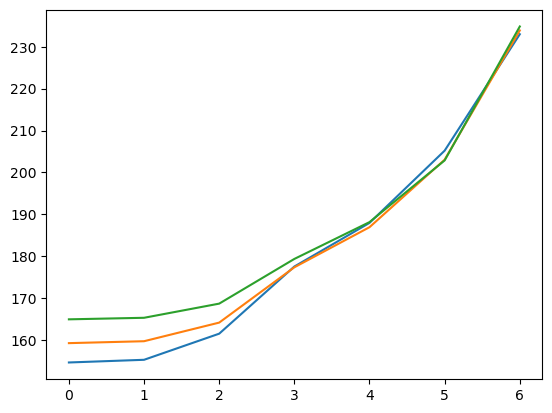

horizontal polarized TB for Ts=271,281,291


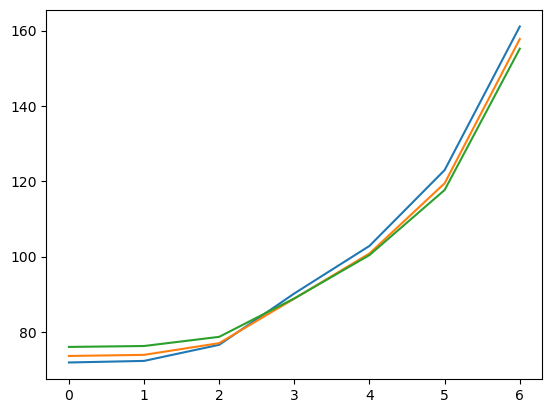

(3, 1, 14)
vertical polarized Em for Ts=271,281,291


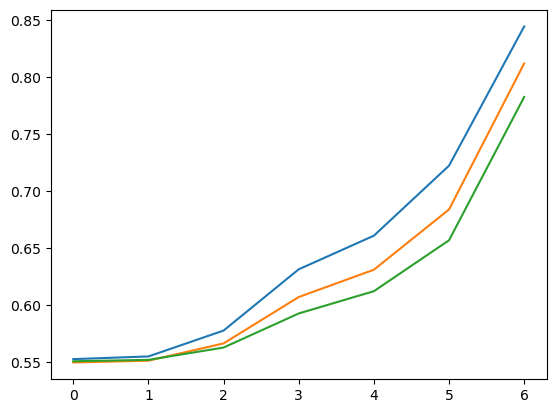

horizontal polarized Em for Ts=271,281,291


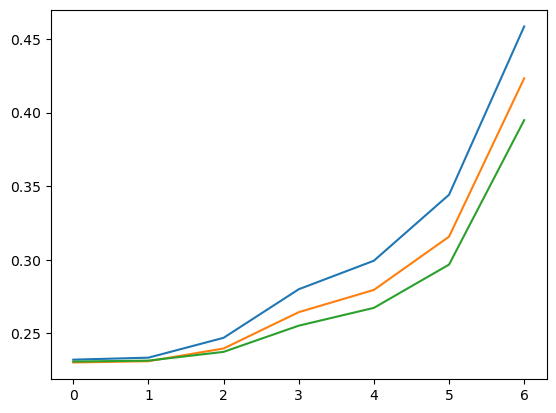

In [48]:
class _profiles_data():
    pass

profiles_data=_profiles_data()

nprofiles = 3
nlevels = 37
nlayers= nlevels-1
nsurfaces = 1
rttov.BaseConf.keys()
conf = rttov.BaseConf.read_conf(1) # 0 = open water, 1 = sea ice

T_surf_water1 = 268.0  # surface air temp for water profile (K)
T_surf_water2 = 278.0  # surface air temp for water profile (K)
T_surf_water3 = 288.0  # surface air temp for water profile (K)
T_top   = 210.0       # temperature at top of atmosphere (K)
profiles_data.T = np.vstack([np.linspace(T_top, T_surf_water1, nlayers), np.linspace(T_top, T_surf_water2, nlayers),np.linspace(T_top, T_surf_water3, nlayers)])  # shape (2,37)

q_surf_water1 = 0.0032  # surface air temp for water profile (K)
q_surf_water2 = 0.0032  # surface air temp for water profile (K)
q_surf_water3 = 0.0032  # surface air temp for water profile (K)
q_top = 1.0E-9
profiles_data.Q = np.vstack([np.linspace(q_top, q_surf_water1, nlayers), np.linspace(q_top, q_surf_water2, nlayers),np.linspace(q_top, q_surf_water3, nlayers)])  # shape (2,37)


profiles_data.SurfType = np.array([[1, 0],[1, 0],[1, 0]]).reshape([3,1,2])
print(profiles_data.SurfType[1])

# Surface geometry: latitude, longitude, elevation for each profile
# [nprofiles,nsurfaces,9]: skin T, salinity, snow_frac, foam_frac, fastem_coefsx5
profiles_data.Skin = np.zeros([nprofiles, 9])
# Profile 0 (open water)
profiles_data.Skin[0,0] = 271.0   # skin temperature of water (K)
profiles_data.Skin[0,1] = 35.0    # sea water salinity (psu, typical ocean)
profiles_data.Skin[0,2] = 0.0     # snow fraction (not applicable to open water)
profiles_data.Skin[0,3] = 0.0     # foam fraction (let RTTOV/FASTEM compute based on wind)
# fastem_coefs[0..4] leave as 0 to use model's default behavior
# Profile 1 (sea-ice)
profiles_data.Skin[1,0] = 281.0   # skin temperature of sea-ice surface (K)
profiles_data.Skin[1,1] = 35.0     # salinity (not a water surface, but set 0)
profiles_data.Skin[1,2] = 0.0     # snow fraction on sea-ice (50% of surface covered by snow)
profiles_data.Skin[1,3] = 0.0     # foam fraction (no foam on ice)
# Profile 1 (sea-ice)
profiles_data.Skin[2,0] = 291.0   # skin temperature of sea-ice surface (K)
profiles_data.Skin[2,1] = 35.0     # salinity (not a water surface, but set 0)
profiles_data.Skin[2,2] = 0.0     # snow fraction on sea-ice (50% of surface covered by snow)
profiles_data.Skin[2,3] = 0.0     # foam fraction (no foam on ice)

# fastem_coefs for ice not used; leave as 0
# (The Skin array includes placeholders for FASTEM parameters; RTTOV uses these for ocean surface calc)
# near_surface[5][nsurfaces][nprofiles]: 2m t, 2m q, 10m wind u, v, wind fetch
# Profile 0 (open water) Profile 1 (sea-ice)
profiles_data.NearSurface = np.zeros([nprofiles, 5])
profiles_data.NearSurface[0,:] = np.array([271.0, 0.0032, 0.0, 0.0, 100000.])
profiles_data.NearSurface[1,:] = np.array([281.0, 0.0032, 0.0, 0.0, 100000.])
profiles_data.NearSurface[2,:] = np.array([291.0, 0.0032, 0.0, 0.0, 100000.])

myprofile=rttov.Profiles_tool(nprofiles, nlevels, nsurfaces, conf, gas_units=1)
profiles_data.Skin=myprofile.expand_nsurfaces(profiles_data.Skin)
profiles_data.NearSurface=myprofile.expand_nsurfaces(profiles_data.NearSurface)
myprofile.set_PHalf_geomspace(p_surface=1013.0,p_top=0.1)
myprofile.set_general_profiles(date=[2015, 5, 1, 0, 0, 0], geom=[80.0,0.0,0.0])
myprofile.set_profiles_from_obj(profiles_data)
myprofile.confirm_profiles()


coefs={"FileCoef": r"/home/knakata/program/software/rttov140/rtcoef_rttov14/rttov13pred54L/rtcoef_gcom-w_1_amsr2_o3.dat"}
       # "FileHydrotable": r"/home/knakata/program/software/rttov140/rtcoef_rttov14/hydrotable_mw/rttov_hydrotable_gcom-w_amsr2.dat"}

myrttov = rttov.RTTOV_tools(nprofiles, nlevels, nsurfaces, conf, coefs)
myrttov.load_profiles(myprofile.profiles)
myrttov.load_emissivity_atlas()
myrttov.run(mode="forward")

bt=myrttov.get_clearSky_BT()
print(bt.shape)
print("vertical polarized TB for Ts=271,281,291")
plt.plot(bt.T[0::2])
plt.show()
print("horizontal polarized TB for Ts=271,281,291")
plt.plot(bt.T[1::2])
plt.show()


em=myrttov.get_surf_emissivity()
print(em.shape)
print("vertical polarized Em for Ts=271,281,291")
plt.plot(em.T[0::2,0])
plt.show()
print("horizontal polarized Em for Ts=271,281,291")
plt.plot(em.T[1::2,0])
plt.show()
